<a href="https://colab.research.google.com/github/vr11-ai/AiModels/blob/main/EmailSpamDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
Data loaded!

Accuracy: 0.9444

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61      0.75       150

    accuracy                           0.94      1115
   macro avg       0.96      0.80      0.86      1115
weighted avg       0.95      0.94      0.94      1115



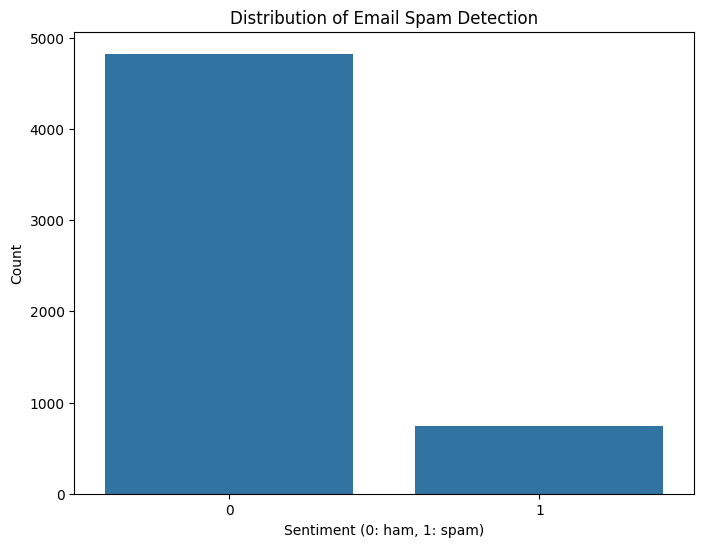

Adjusted Accuracy (Balanced Accuracy): 0.8018


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from google.colab import drive
from sklearn.metrics import balanced_accuracy_score

drive.mount('/content/drive')

print("Loading data...")
df=pd.read_csv('/content/drive/MyDrive/datasets/spam.csv', encoding='latin1')
print("Data loaded!\n")

# 2. Data Cleaning
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.columns = ['label', 'message']

# Encode labels: ham (not spam) -> 0, spam -> 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# 3. Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer(stop_words='english', lowercase=True)
X = tfidf.fit_transform(df['message'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# 6. Model Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribution of Email Spam Detection')
plt.xlabel('Sentiment (0: ham, 1: spam)')
plt.ylabel('Count')
plt.show()

adjusted_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Adjusted Accuracy (Balanced Accuracy): {adjusted_accuracy:.4f}")


In [ ]:
# 7. Visualization: Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Spam Classification')
plt.savefig('confusion_matrix.png')